# Support Vector Regression (SVR) s lineárním jádrem

## Co je SVR s lineárním jádrem?

Support Vector Regression (SVR) je varianta Support Vector Machines (SVM) určená pro regresní úlohy. Stejně jako SVM pro klasifikaci, SVR vytváří model, který závisí pouze na podmnožině trénovacích dat (tzv. podpůrných vektorech), ale namísto predikce tříd predikuje spojité hodnoty.

### Princip SVR s lineárním jádrem:

SVR s lineárním jádrem se snaží najít lineární funkci, která se od pozorovaných hodnot odchyluje maximálně o hodnotu epsilon (ε), a zároveň je co nejplošší (má co nejmenší normu koeficientů). Jinými slovy, vytváří "epsilon-trubici" okolo predikční funkce a penalizuje pouze body, které leží mimo tuto trubici.

### Matematický popis:

SVR minimalizuje následující funkci:

$$\min_{w, b} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$$

Za podmínek:
- $y_i - (w^T x_i + b) \leq \varepsilon + \xi_i$
- $(w^T x_i + b) - y_i \leq \varepsilon + \xi_i^*$
- $\xi_i, \xi_i^* \geq 0$

kde:
- $w$ je vektor vah (koeficientů)
- $b$ je bias
- $\varepsilon$ je maximální povolená odchylka
- $C$ je regularizační parametr pro penalizaci bodů mimo epsilon-trubici
- $\xi_i, \xi_i^*$ jsou pomocné proměnné pro body nad nebo pod epsilon-trubicí

### Hlavní parametry SVR:

1. **C**: Regularizační parametr, který určuje trade-off mezi plochostí funkce a mírou tolerance odchylek větších než epsilon. Větší C znamená méně regularizace.
2. **epsilon (ε)**: Definuje šířku epsilon-trubice, ve které se nepenalizují odchylky od pozorovaných hodnot.
3. **kernel**: V našem případě "linear", což znamená, že hledáme lineární vztah mezi vstupními proměnnými a cílovou hodnotou.

### Kdy použít SVR s lineárním jádrem:

- Když předpokládáte lineární vztah mezi příznaky a cílovou proměnnou
- Když potřebujete robustnost vůči odlehlým hodnotám (na rozdíl od běžné lineární regrese)
- Když chcete kontrolu nad mírou přesnosti predikce pomocí parametru epsilon
- Když váš dataset nemá příliš mnoho příznaků (pro vysokodimenzionální data může být výpočetně náročné)

In [1]:
# Import potřebných knihoven
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import make_regression, fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge
import time

# Nastavení pro reprodukovatelnost
np.random.seed(42)

# Nastavení vizualizací
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette('viridis')

## 1. Základní pochopení SVR s lineárním jádrem na jednoduchém příkladu

Začneme vytvořením jednoduchého syntetického datasetu, na kterém si ukážeme, jak SVR s lineárním jádrem funguje a jaký je vliv hlavních parametrů.

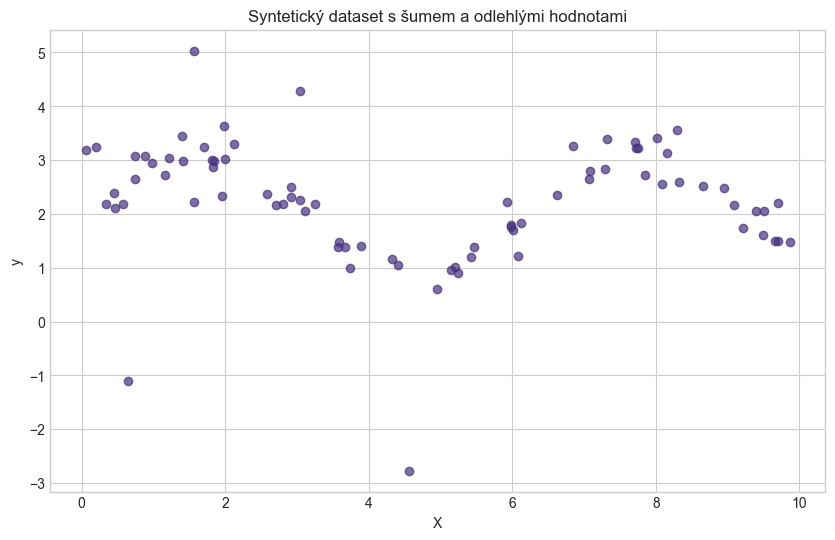

In [2]:
# Vytvoření jednoduchého 1D syntetického datasetu s šumem a odlehlými hodnotami
def create_simple_dataset(n_samples=100, noise=0.5, outliers=10, random_state=42):
    rng = np.random.RandomState(random_state)
    
    # Tvorba základních dat
    X = np.sort(rng.rand(n_samples)) * 10
    y = np.sin(X) + 2 + noise * rng.randn(n_samples)
    
    # Přidání odlehlých hodnot
    if outliers > 0:
        outlier_indices = rng.randint(0, n_samples, outliers)
        y[outlier_indices] += rng.normal(0, 3, outliers)
    
    # Převod na dvourozměrná pole pro scikit-learn
    X = X.reshape(-1, 1)
    
    return X, y

# Vytvoření datasetu
X_simple, y_simple = create_simple_dataset(n_samples=80, noise=0.3, outliers=8)

# Vizualizace dat
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y_simple, alpha=0.7)
plt.title('Syntetický dataset s šumem a odlehlými hodnotami')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()

SVR s lineárním jádrem (výchozí parametry):
  MSE: 0.7568
  R²: -0.0925


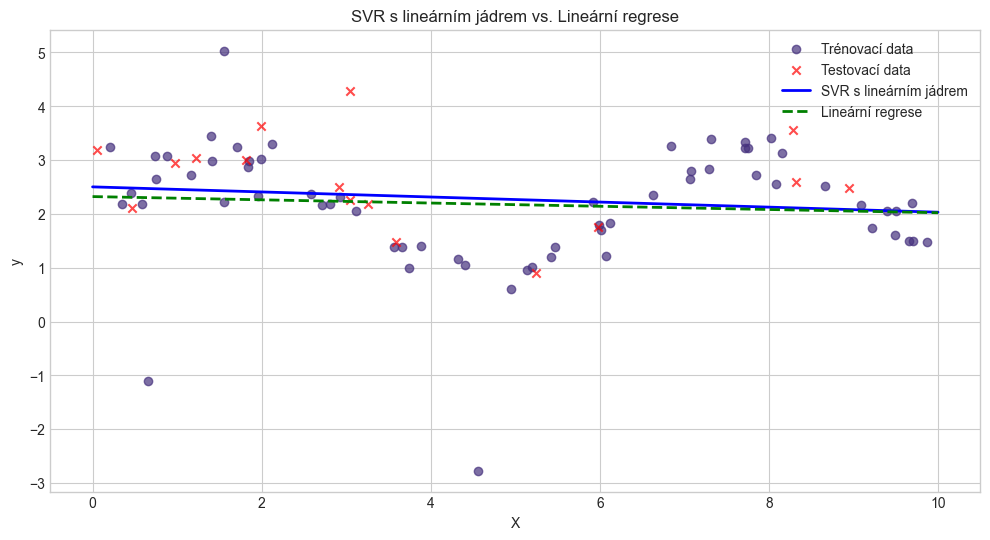

In [3]:
# Rozdělení na trénovací a testovací data
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Vytvoření a trénování SVR s lineárním jádrem s výchozími parametry
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train, y_train)

# Vytvoření dat pro vizualizaci predikce
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred_linear = svr_linear.predict(X_plot)

# Vyhodnocení na testovacích datech
y_pred_test = svr_linear.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_test)
r2_linear = r2_score(y_test, y_pred_test)

print(f"SVR s lineárním jádrem (výchozí parametry):")
print(f"  MSE: {mse_linear:.4f}")
print(f"  R²: {r2_linear:.4f}")

# Vizualizace výsledků
plt.figure(figsize=(12, 6))
plt.scatter(X_train, y_train, alpha=0.7, label='Trénovací data')
plt.scatter(X_test, y_test, alpha=0.7, marker='x', color='red', label='Testovací data')
plt.plot(X_plot, y_pred_linear, color='blue', linewidth=2, label='SVR s lineárním jádrem')

# Pro porovnání přidáme ještě běžnou lineární regresi
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_plot)
plt.plot(X_plot, y_pred_lr, color='green', linestyle='--', linewidth=2, label='Lineární regrese')

plt.title('SVR s lineárním jádrem vs. Lineární regrese')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### Vliv parametrů C a epsilon na SVR

Podívejme se, jak dva hlavní parametry SVR ovlivňují výsledný model:
1. **C** - regularizační parametr (vyšší C = méně regularizace = složitější model)
2. **epsilon** - šířka "trubice", ve které nejsou chyby penalizovány

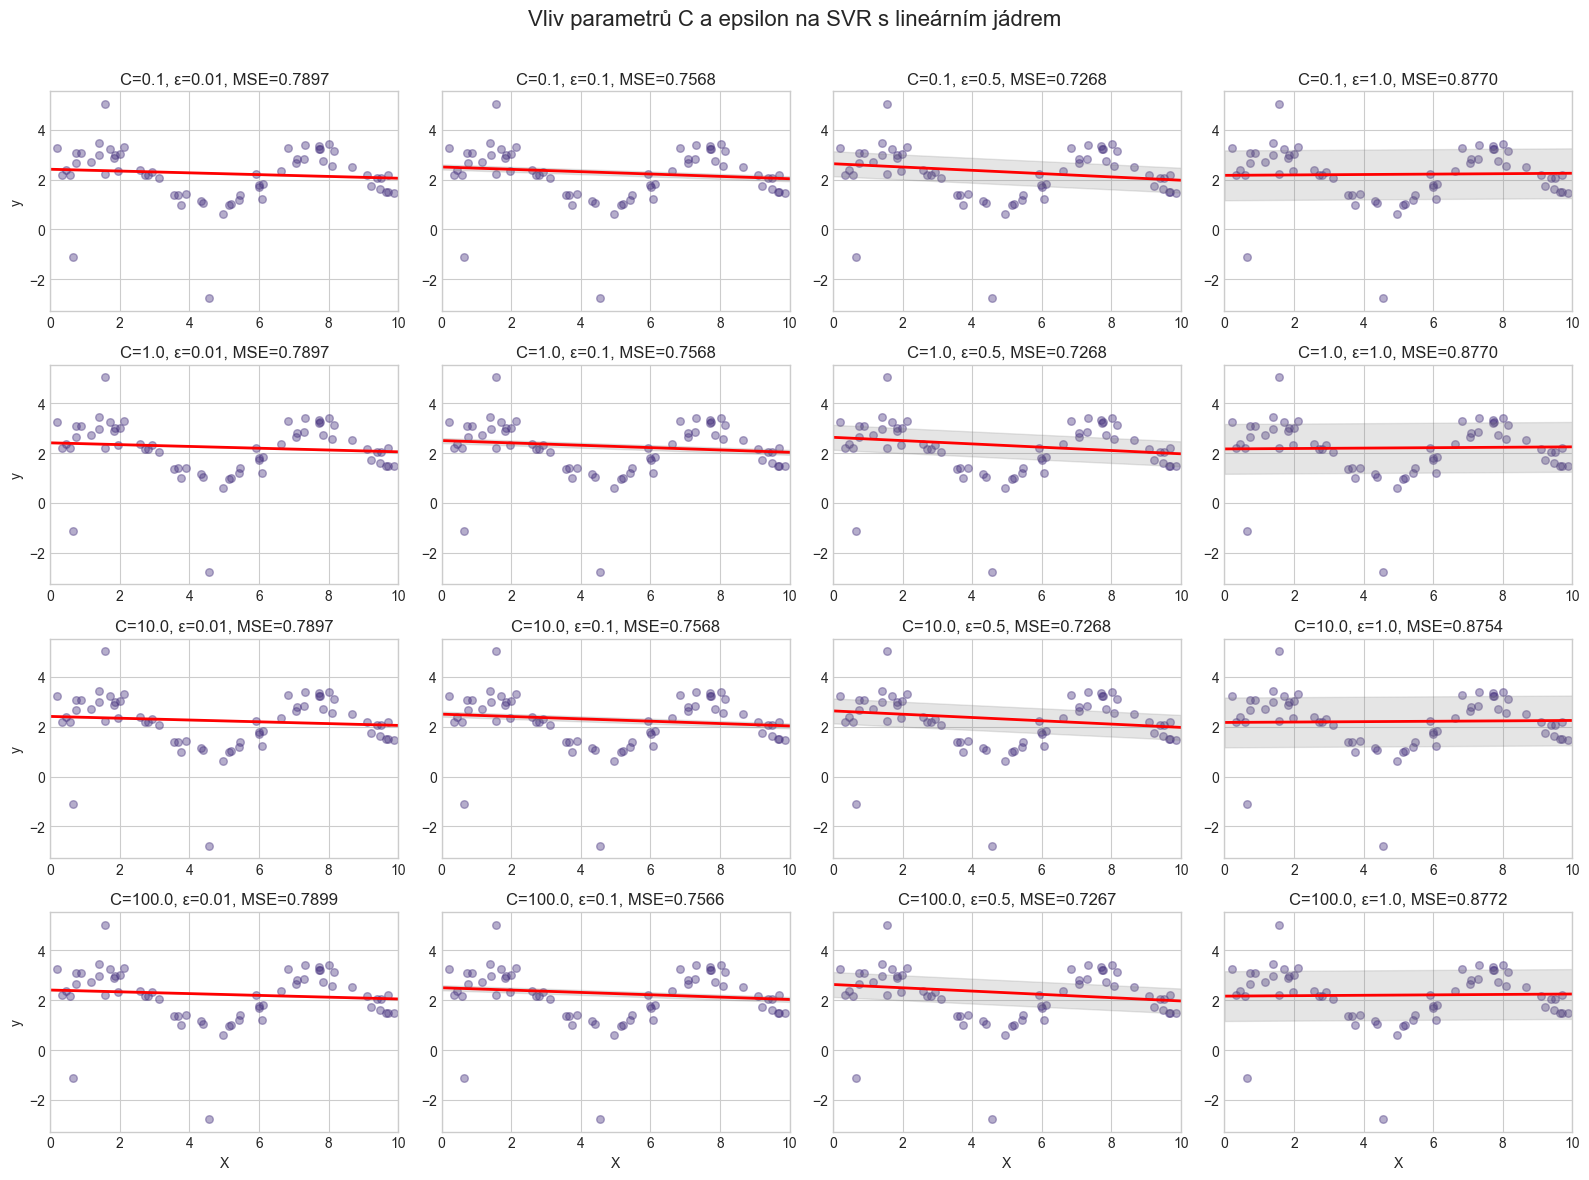

In [4]:
# Zkoumání vlivu parametrů C a epsilon
C_values = [0.1, 1.0, 10.0, 100.0]
epsilon_values = [0.01, 0.1, 0.5, 1.0]

# Vytvoření mřížky grafů
fig, axes = plt.subplots(len(C_values), len(epsilon_values), figsize=(16, 12))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i, C in enumerate(C_values):
    for j, epsilon in enumerate(epsilon_values):
        ax = axes[i, j]
        
        # Trénování SVR s konkrétními parametry
        svr = SVR(kernel='linear', C=C, epsilon=epsilon)
        svr.fit(X_train, y_train)
        
        # Predikce
        y_pred = svr.predict(X_plot)
        
        # Vyhodnocení
        y_pred_test_param = svr.predict(X_test)
        mse = mean_squared_error(y_test, y_pred_test_param)
        
        # Vizualizace
        ax.scatter(X_train[:, 0], y_train, alpha=0.4, s=30)
        ax.plot(X_plot, y_pred, color='red', linewidth=2)
        
        # Vykreslení epsilon-trubice
        ax.fill_between(X_plot.ravel(),
                       y_pred - epsilon,
                       y_pred + epsilon,
                       alpha=0.2, color='gray')
        
        ax.set_title(f"C={C}, ε={epsilon}, MSE={mse:.4f}")
        ax.grid(True)
        
        # Nastavení stejných os pro lepší srovnání
        ax.set_xlim(0, 10)
        ax.set_ylim(min(y_simple) - 0.5, max(y_simple) + 0.5)
        
        # Popisky os pouze na okrajových grafech
        if i == len(C_values) - 1:
            ax.set_xlabel('X')
        if j == 0:
            ax.set_ylabel('y')

plt.suptitle('Vliv parametrů C a epsilon na SVR s lineárním jádrem', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 2. Srovnání SVR s lineárním jádrem s jinými regresními modely

Porovnáme SVR s lineárním jádrem s dalšími běžnými regresními modely na složitějším syntetickém datasetu s více příznaky.

In [5]:
# Vytvoření složitějšího datasetu s více příznaky
X_multi, y_multi = make_regression(n_samples=200, n_features=5, noise=20, random_state=42)

# Přidání odlehlých hodnot
rng = np.random.RandomState(42)
outlier_indices = rng.randint(0, X_multi.shape[0], 15)
y_multi[outlier_indices] += rng.normal(0, 80, 15)

# Rozdělení na trénovací a testovací data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42)

# Standardizace dat
scaler = StandardScaler()
X_train_multi_scaled = scaler.fit_transform(X_train_multi)
X_test_multi_scaled = scaler.transform(X_test_multi)

# Definice modelů pro srovnání
models = {
    'Lineární regrese': LinearRegression(),
    'Ridge regrese': Ridge(alpha=1.0),
    'SVR (lineární)': SVR(kernel='linear', C=1.0, epsilon=0.1),
    'SVR (RBF)': SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
}

# Trénování a vyhodnocení modelů
results = []

for name, model in models.items():
    # Měření času trénování
    start_time = time.time()
    model.fit(X_train_multi_scaled, y_train_multi)
    train_time = time.time() - start_time
    
    # Predikce
    y_pred = model.predict(X_test_multi_scaled)
    
    # Výpočet metrik
    mse = mean_squared_error(y_test_multi, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_multi, y_pred)
    r2 = r2_score(y_test_multi, y_pred)
    
    # Uložení výsledků
    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Čas trénování (s)': train_time
    })

# Převod výsledků na DataFrame a výpis
results_df = pd.DataFrame(results)
print("Srovnání regresních modelů:")
print(results_df.round(4))

Srovnání regresních modelů:
              Model        MSE     RMSE      MAE      R²  Čas trénování (s)
0  Lineární regrese   373.8985  19.3365  15.7473  0.9572              0.001
1     Ridge regrese   369.9336  19.2337  15.6168  0.9577              0.001
2    SVR (lineární)   609.7985  24.6941  19.5559  0.9302              0.002
3         SVR (RBF)  7915.1399  88.9671  71.6076  0.0941              0.001


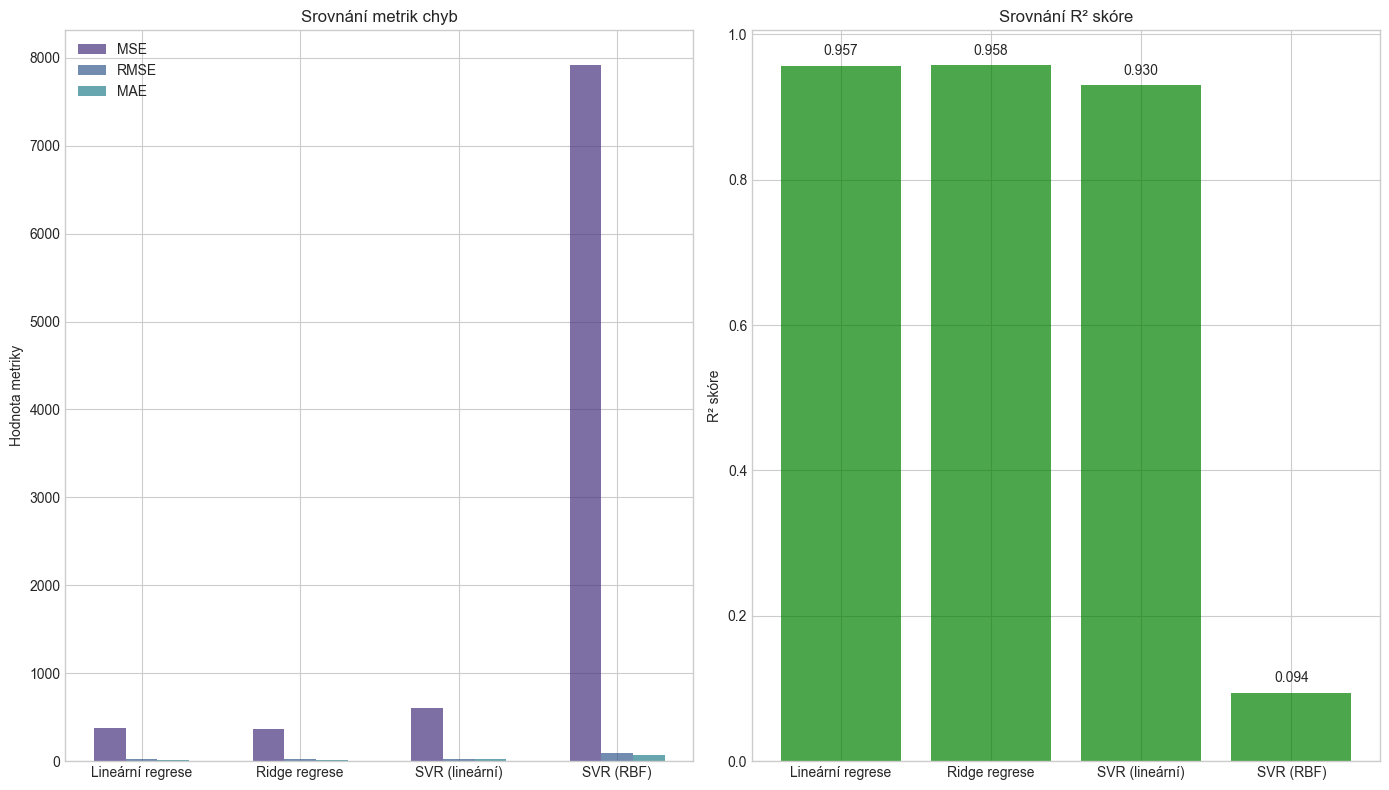

In [6]:
# Vizualizace výsledků srovnání
plt.figure(figsize=(14, 8))

# Vizualizace metrik
metrics = ['MSE', 'RMSE', 'MAE']
plt.subplot(1, 2, 1)

for i, metric in enumerate(metrics):
    plt.bar([x + i*0.2 for x in range(len(models))], results_df[metric], width=0.2, 
            label=metric, alpha=0.7)
    
plt.xticks([x + 0.2 for x in range(len(models))], results_df['Model'])
plt.ylabel('Hodnota metriky')
plt.title('Srovnání metrik chyb')
plt.legend()
plt.grid(True, axis='y')

# Vizualizace R2
plt.subplot(1, 2, 2)
bars = plt.bar(results_df['Model'], results_df['R²'], color='green', alpha=0.7)
plt.ylabel('R² skóre')
plt.title('Srovnání R² skóre')
plt.grid(True, axis='y')

# Přidání hodnot na vrcholy sloupců
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom')
    
plt.tight_layout()
plt.show()

## 3. Hledání optimálních parametrů SVR

Použijeme GridSearchCV pro nalezení optimálních parametrů C a epsilon pro SVR s lineárním jádrem.

In [7]:
# Definice parametrů pro GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.5, 1.0]
}

# Vytvoření modelu SVR
svr = SVR(kernel='linear')

# Nastavení GridSearchCV
grid_search = GridSearchCV(
    svr, param_grid, cv=5, scoring='neg_mean_squared_error', 
    verbose=1, n_jobs=-1
)

# Provedení Grid Search
grid_search.fit(X_train_multi_scaled, y_train_multi)

# Výpis nejlepších parametrů
print(f"Nejlepší parametry: {grid_search.best_params_}")
print(f"Nejlepší skóre (neg MSE): {grid_search.best_score_:.4f}")

# Evaluace nejlepšího modelu
best_svr = grid_search.best_estimator_
y_pred_best = best_svr.predict(X_test_multi_scaled)

mse_best = mean_squared_error(y_test_multi, y_pred_best)
r2_best = r2_score(y_test_multi, y_pred_best)

print(f"\nVýkon nejlepšího SVR modelu na testovacích datech:")
print(f"  MSE: {mse_best:.4f}")
print(f"  RMSE: {np.sqrt(mse_best):.4f}")
print(f"  R²: {r2_best:.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Nejlepší parametry: {'C': 100, 'epsilon': 1.0}
Nejlepší skóre (neg MSE): -1430.3316

Výkon nejlepšího SVR modelu na testovacích datech:
  MSE: 325.3300
  RMSE: 18.0369
  R²: 0.9628


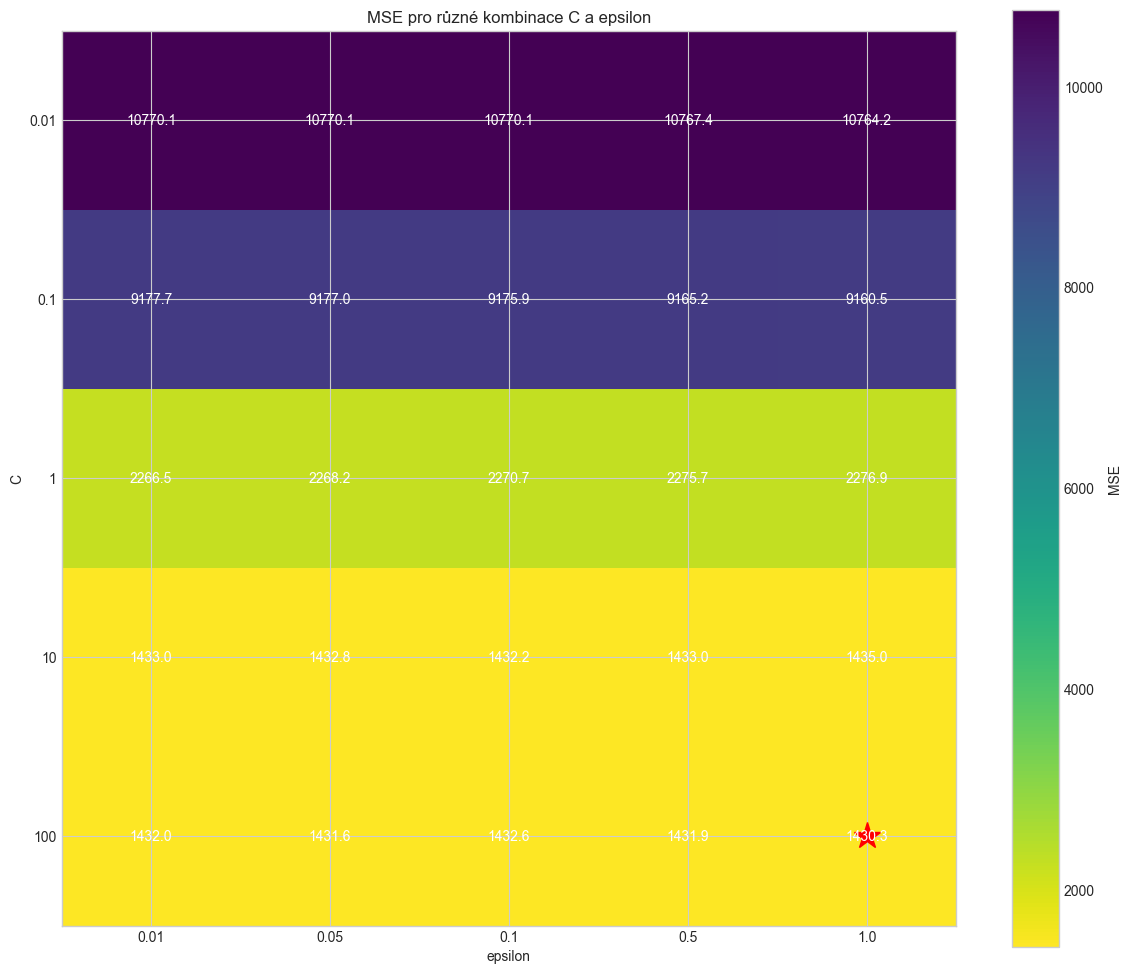

In [8]:
# Vizualizace výsledků Grid Search
results = grid_search.cv_results_

# Vytvoření matice skóre pro různé kombinace C a epsilon
scores = np.array(results['mean_test_score']).reshape(len(param_grid['C']), len(param_grid['epsilon']))
scores = -scores  # Převod zpět na MSE z neg_mean_squared_error

plt.figure(figsize=(12, 10))
plt.imshow(scores, interpolation='nearest', cmap=plt.cm.viridis_r)
plt.xlabel('epsilon')
plt.ylabel('C')
plt.colorbar(label='MSE')
plt.xticks(np.arange(len(param_grid['epsilon'])), param_grid['epsilon'])
plt.yticks(np.arange(len(param_grid['C'])), param_grid['C'])
plt.title('MSE pro různé kombinace C a epsilon')

# Zvýraznění nejlepší kombinace
best_c_idx = param_grid['C'].index(grid_search.best_params_['C'])
best_e_idx = param_grid['epsilon'].index(grid_search.best_params_['epsilon'])
plt.plot(best_e_idx, best_c_idx, 'r*', markersize=20)

# Přidání hodnot do matice
for i in range(len(param_grid['C'])):
    for j in range(len(param_grid['epsilon'])):
        plt.text(j, i, f"{scores[i, j]:.1f}", 
                 ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

## 4. Aplikace SVR na reálný dataset

Použijeme California Housing dataset pro testování SVR s lineárním jádrem na reálných datech.

In [9]:
# Načtení California Housing datasetu
housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target

# Informace o datasetu
print(f"California Housing Dataset:")
print(f"  Počet vzorků: {X_housing.shape[0]}")
print(f"  Počet příznaků: {X_housing.shape[1]}")
print(f"  Příznaky: {housing.feature_names}")
print("\nPopisná statistika cílové proměnné:")
print(f"  Minimum: {y_housing.min():.2f}")
print(f"  Maximum: {y_housing.max():.2f}")
print(f"  Průměr: {y_housing.mean():.2f}")
print(f"  Medián: {np.median(y_housing):.2f}")
print(f"  Směrodatná odchylka: {y_housing.std():.2f}")

# Pro urychlení výpočtů použijeme podmnožinu dat
rng = np.random.RandomState(42)
indices = rng.choice(X_housing.shape[0], 5000, replace=False)
X_housing_subset = X_housing[indices]
y_housing_subset = y_housing[indices]

# Rozdělení na trénovací a testovací data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing_subset, y_housing_subset, test_size=0.2, random_state=42)

California Housing Dataset:
  Počet vzorků: 20640
  Počet příznaků: 8
  Příznaky: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Popisná statistika cílové proměnné:
  Minimum: 0.15
  Maximum: 5.00
  Průměr: 2.07
  Medián: 1.80
  Směrodatná odchylka: 1.15


In [10]:
# Vytvoření pipeline s předzpracováním a SVR
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='linear', C=1.0, epsilon=0.1))
])

# Trénování modelu
start_time = time.time()
svr_pipeline.fit(X_train_h, y_train_h)
train_time = time.time() - start_time

# Predikce
y_pred_h = svr_pipeline.predict(X_test_h)

# Vyhodnocení výkonu
mse_h = mean_squared_error(y_test_h, y_pred_h)
rmse_h = np.sqrt(mse_h)
mae_h = mean_absolute_error(y_test_h, y_pred_h)
r2_h = r2_score(y_test_h, y_pred_h)

print(f"SVR s lineárním jádrem na California Housing datasetu:")
print(f"  Čas trénování: {train_time:.2f} sekund")
print(f"  MSE: {mse_h:.4f}")
print(f"  RMSE: {rmse_h:.4f}")
print(f"  MAE: {mae_h:.4f}")
print(f"  R²: {r2_h:.4f}")

SVR s lineárním jádrem na California Housing datasetu:
  Čas trénování: 1.33 sekund
  MSE: 0.4888
  RMSE: 0.6991
  MAE: 0.4924
  R²: 0.6381


In [11]:
# Porovnání s ostatními modely
models_h = {
    'Lineární regrese': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge regrese': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'SVR (lineární)': Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='linear', C=1.0, epsilon=0.1))]),
    'SVR (RBF)': Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf', C=10.0, epsilon=0.1))])
}

results_h = []

for name, pipeline in models_h.items():
    # Cross-validace pro robustnější porovnání
    cv_scores = cross_val_score(pipeline, X_housing_subset, y_housing_subset, 
                               cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    
    # Trénování na celém trénovacím setu
    pipeline.fit(X_train_h, y_train_h)
    y_pred = pipeline.predict(X_test_h)
    
    # Metriky
    mse = mean_squared_error(y_test_h, y_pred)
    r2 = r2_score(y_test_h, y_pred)
    
    # Uložení výsledků
    results_h.append({
        'Model': name,
        'MSE (Test)': mse,
        'RMSE (Test)': np.sqrt(mse),
        'R² (Test)': r2,
        'MSE (CV)': -np.mean(cv_scores),
        'MSE (CV) Std': np.std(cv_scores)
    })

# Výpis výsledků
results_h_df = pd.DataFrame(results_h)
print("Srovnání modelů na California Housing datasetu:")
print(results_h_df.round(4))

Srovnání modelů na California Housing datasetu:
              Model  MSE (Test)  RMSE (Test)  R² (Test)  MSE (CV)  \
0  Lineární regrese      0.5012       0.7080     0.6289    0.5420   
1     Ridge regrese      0.5012       0.7080     0.6289    0.5419   
2    SVR (lineární)      0.4888       0.6991     0.6381    0.6159   
3         SVR (RBF)      0.3591       0.5992     0.7342    0.3185   

   MSE (CV) Std  
0        0.0583  
1        0.0582  
2        0.1368  
3        0.0211  


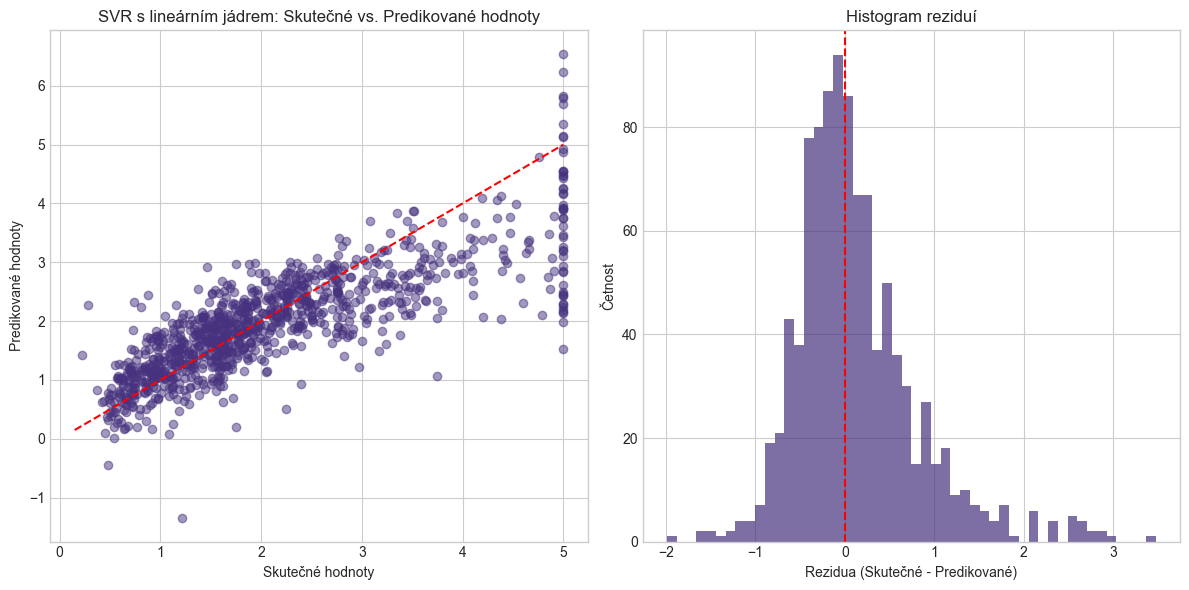

In [12]:
# Vizualizace skutečných vs. predikovaných hodnot pro SVR s lineárním jádrem
plt.figure(figsize=(12, 6))

# Získání predikce z SVR modelu
svr_pipeline = models_h['SVR (lineární)']
y_pred_svr = svr_pipeline.predict(X_test_h)

# Skutečné vs. predikované hodnoty
plt.subplot(1, 2, 1)
plt.scatter(y_test_h, y_pred_svr, alpha=0.5)
plt.plot([y_housing_subset.min(), y_housing_subset.max()], 
         [y_housing_subset.min(), y_housing_subset.max()], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Predikované hodnoty')
plt.title('SVR s lineárním jádrem: Skutečné vs. Predikované hodnoty')
plt.grid(True)

# Histogram reziduí
plt.subplot(1, 2, 2)
residuals = y_test_h - y_pred_svr
plt.hist(residuals, bins=50, alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--')
plt.xlabel('Rezidua (Skutečné - Predikované)')
plt.ylabel('Četnost')
plt.title('Histogram reziduí')
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# # Analýza koeficientů SVR modelu
# svr_model = models_h['SVR (lineární)'].named_steps['model']
# scaler = models_h['SVR (lineární)'].named_steps['scaler']

# # Získání koeficientů
# coefs = svr_model.coef_[0]

# # Transformace koeficientů zpět do původní škály
# coefs_original = coefs / scaler.scale_

# # Vytvoření DataFrame s koeficienty
# coefs_df = pd.DataFrame({
#     'Feature': housing.feature_names,
#     'Coefficient': coefs,
#     'Abs_Coefficient': np.abs(coefs)
# }).sort_values(by='Abs_Coefficient', ascending=False)

# # Vizualizace koeficientů
# plt.figure(figsize=(12, 8))
# sns.barplot(x='Coefficient', y='Feature', data=coefs_df, palette='viridis')
# plt.title('Koeficienty SVR s lineárním jádrem')
# plt.axvline(x=0, color='r', linestyle='--')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Výpis koeficientů
# print("Koeficienty SVR modelu (seřazeno podle absolutní hodnoty):")
# for i, row in coefs_df.iterrows():
#     print(f"{row['Feature']}: {row['Coefficient']:.4f}")

```
FutureWarning: 
Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
```

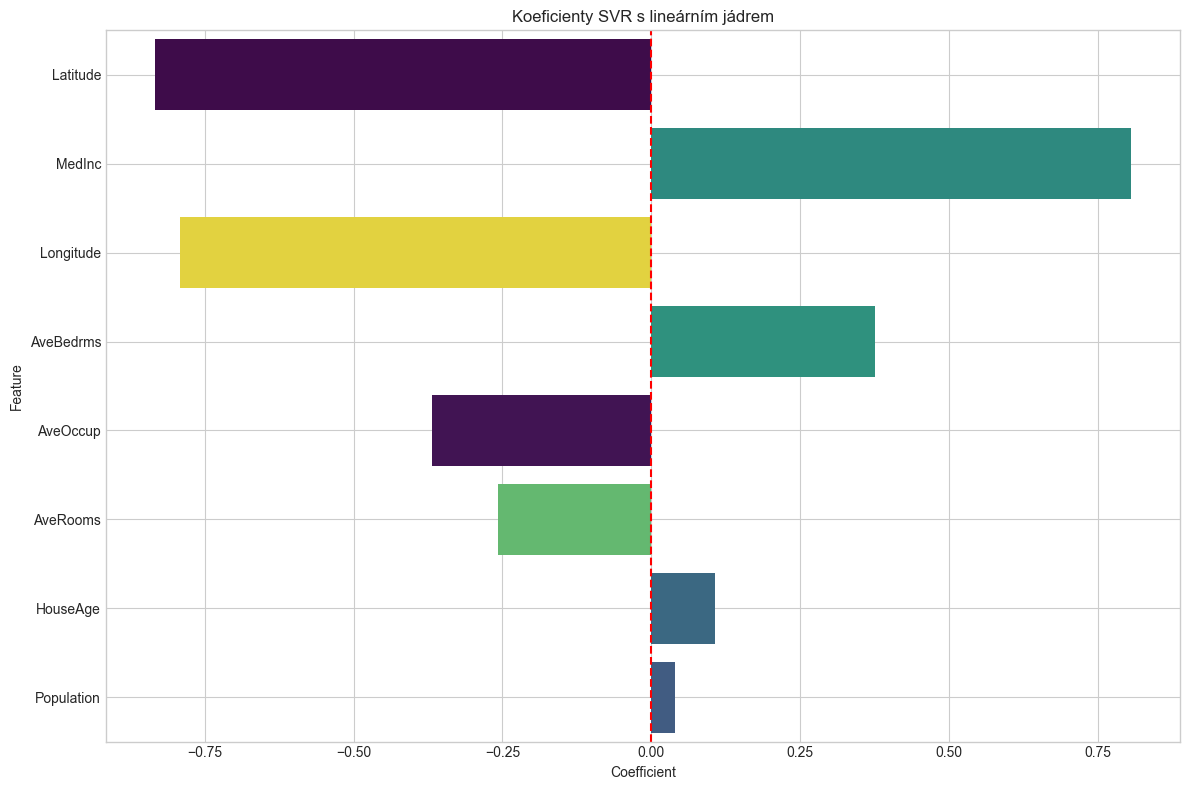

Koeficienty SVR modelu (seřazeno podle absolutní hodnoty):
Latitude: -0.8341
MedInc: 0.8060
Longitude: -0.7914
AveBedrms: 0.3753
AveOccup: -0.3676
AveRooms: -0.2580
HouseAge: 0.1064
Population: 0.0401


In [14]:
# Analýza koeficientů SVR modelu
svr_model = models_h['SVR (lineární)'].named_steps['model']
scaler = models_h['SVR (lineární)'].named_steps['scaler']

# Získání koeficientů
coefs = svr_model.coef_[0]

# Transformace koeficientů zpět do původní škály
coefs_original = coefs / scaler.scale_

# Vytvoření DataFrame s koeficienty
coefs_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': coefs,
    'Abs_Coefficient': np.abs(coefs)
}).sort_values(by='Abs_Coefficient', ascending=False)

# Přidání barvy na základě hodnoty koeficientu
from matplotlib import cm
from matplotlib.colors import Normalize

norm = Normalize(vmin=coefs_df['Coefficient'].min(), vmax=coefs_df['Coefficient'].max())
colors = cm.viridis(norm(coefs_df['Coefficient'].values))

# Convert colors to list to avoid UserWarning
colors_list = [tuple(color) for color in colors]

# Vizualizace koeficientů
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefs_df, palette=colors_list, hue='Coefficient', legend=False)
plt.title('Koeficienty SVR s lineárním jádrem')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()

# Výpis koeficientů
print("Koeficienty SVR modelu (seřazeno podle absolutní hodnoty):")
for i, row in coefs_df.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.4f}")

## 5. Robustnost SVR vůči odlehlým hodnotám

Jednou z hlavních výhod SVR je jeho odolnost vůči odlehlým hodnotám díky epsilon-insensitive loss function. Porovnáme SVR s lineárním jádrem s běžnou lineární regresí na datasetu s odlehlými hodnotami.

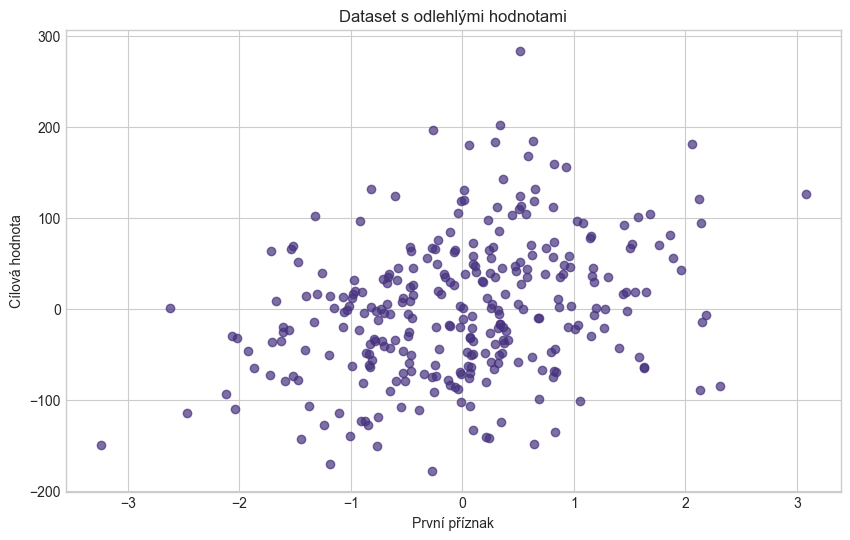

In [15]:
# Vytvoření datasetu s odlehlými hodnotami
def create_outlier_dataset(n_samples=200, n_features=2, outlier_ratio=0.1, outlier_strength=30, random_state=42):
    """Vytvoří dataset s odlehlými hodnotami"""
    X, y = make_regression(n_samples=n_samples, n_features=n_features, noise=5, random_state=random_state)
    
    # Přidání silných odlehlých hodnot
    rng = np.random.RandomState(random_state)
    n_outliers = int(n_samples * outlier_ratio)
    outlier_indices = rng.choice(n_samples, n_outliers, replace=False)
    y[outlier_indices] += rng.normal(0, outlier_strength, n_outliers)
    
    return X, y

# Vytvoření datasetu
X_out, y_out = create_outlier_dataset(n_samples=300, n_features=2, outlier_ratio=0.15)

# Rozdělení na trénovací a testovací data
X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(X_out, y_out, test_size=0.2, random_state=42)

# Standardizace
scaler_out = StandardScaler()
X_train_out_scaled = scaler_out.fit_transform(X_train_out)
X_test_out_scaled = scaler_out.transform(X_test_out)

# Vizualizace datasetu
plt.figure(figsize=(10, 6))
plt.scatter(X_out[:, 0], y_out, alpha=0.7)
plt.xlabel('První příznak')
plt.ylabel('Cílová hodnota')
plt.title('Dataset s odlehlými hodnotami')
plt.grid(True)
plt.show()

In [16]:
# Porovnání SVR s lineární regresí na datasetu s odlehlými hodnotami
models_out = {
    'Lineární regrese': LinearRegression(),
    'SVR (lineární, C=1)': SVR(kernel='linear', C=1.0, epsilon=0.1),
    'SVR (lineární, C=10)': SVR(kernel='linear', C=10.0, epsilon=0.1),
    'SVR (lineární, C=0.1)': SVR(kernel='linear', C=0.1, epsilon=0.1)
}

# Trénování a predikce
results_out = {}

for name, model in models_out.items():
    # Trénování modelu
    model.fit(X_train_out_scaled, y_train_out)
    
    # Predikce
    y_train_pred = model.predict(X_train_out_scaled)
    y_test_pred = model.predict(X_test_out_scaled)
    
    # Metriky
    train_mse = mean_squared_error(y_train_out, y_train_pred)
    test_mse = mean_squared_error(y_test_out, y_test_pred)
    test_r2 = r2_score(y_test_out, y_test_pred)
    
    results_out[name] = {
        'model': model,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'test_r2': test_r2
    }
    
# Výpis výsledků
print("Výsledky na datasetu s odlehlými hodnotami:")
for name, result in results_out.items():
    print(f"{name}:")
    print(f"  MSE (train): {result['train_mse']:.4f}")
    print(f"  MSE (test): {result['test_mse']:.4f}")
    print(f"  R² (test): {result['test_r2']:.4f}")

Výsledky na datasetu s odlehlými hodnotami:
Lineární regrese:
  MSE (train): 23.7990
  MSE (test): 590.9757
  R² (test): 0.9056
SVR (lineární, C=1):
  MSE (train): 27.7400
  MSE (test): 606.7196
  R² (test): 0.9031
SVR (lineární, C=10):
  MSE (train): 24.0195
  MSE (test): 594.8520
  R² (test): 0.9050
SVR (lineární, C=0.1):
  MSE (train): 3049.1209
  MSE (test): 3810.5323
  R² (test): 0.3913


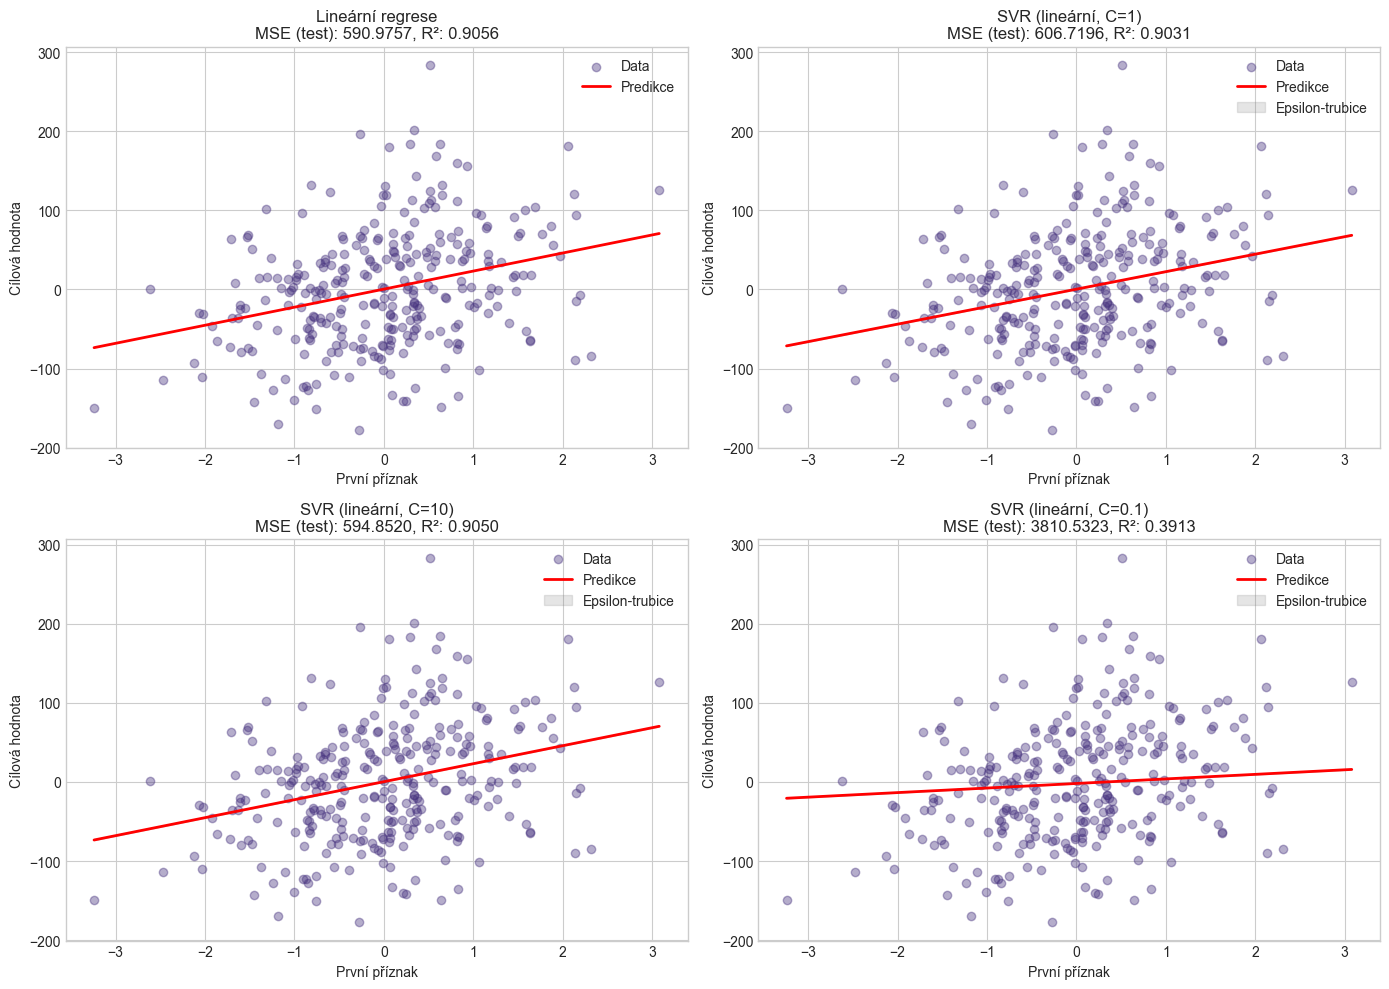

In [17]:
# Vizualizace výsledků různých modelů na datasetu s odlehlými hodnotami
plt.figure(figsize=(14, 10))

# Příprava dat pro vizualizaci predikce
x_feature = 0  # Vizualizujeme pouze podle prvního příznaku pro jednoduchost
x_range = np.linspace(X_out[:, x_feature].min(), X_out[:, x_feature].max(), 100).reshape(-1, 1)
X_viz = np.zeros((100, X_out.shape[1]))
X_viz[:, x_feature] = x_range.ravel()
X_viz_scaled = scaler_out.transform(X_viz)

# Vizualizace každého modelu
for i, (name, result) in enumerate(results_out.items()):
    ax = plt.subplot(2, 2, i+1)
    
    # Data body
    ax.scatter(X_out[:, x_feature], y_out, alpha=0.4, label='Data')
    
    # Predikční křivka
    y_viz = result['model'].predict(X_viz_scaled)
    ax.plot(x_range, y_viz, 'r-', linewidth=2, label='Predikce')
    
    # SVR epsilon-tube (pouze pro SVR modely)
    if 'SVR' in name:
        epsilon = result['model'].epsilon
        ax.fill_between(x_range.ravel(), y_viz - epsilon, y_viz + epsilon, 
                       alpha=0.2, color='gray', label='Epsilon-trubice')
    
    # Nastavení grafu
    ax.set_title(f"{name}\nMSE (test): {result['test_mse']:.4f}, R²: {result['test_r2']:.4f}")
    ax.set_xlabel('První příznak')
    ax.set_ylabel('Cílová hodnota')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Shrnutí vlastností SVR s lineárním jádrem

### Výhody SVR s lineárním jádrem:

1. **Odolnost vůči odlehlým hodnotám** - Díky epsilon-insensitive loss function je SVR méně citlivý na odlehlé hodnoty než běžná lineární regrese.
2. **Kontrola nad přesností modelu** - Parametr epsilon umožňuje explicitně nastavit toleranci pro chyby.
3. **Regularizace** - Parametr C poskytuje možnost regularizace pro prevenci přeučení.
4. **Interpretabilnost** - Při použití lineárního jádra zůstává model interpretovatelný podobně jako lineární regrese.
5. **Robustnost** - SVR často poskytuje stabilnější výsledky na různých datasetech.

### Nevýhody SVR s lineárním jádrem:

1. **Výpočetní náročnost** - Zejména pro velké datasety může být výpočetně náročnější než běžná lineární regrese.
2. **Ladění hyperparametrů** - Vyžaduje pečlivé ladění parametrů C a epsilon pro optimální výkon.
3. **Omezení na lineární vztahy** - Bez použití jiných jader je SVR s lineárním jádrem omezen na lineární vztahy mezi vstupy a výstupy.
4. **Škálování** - Výkon může výrazně záviset na správném předzpracování a škálování dat.

### Nejlepší postupy při použití SVR s lineárním jádrem:

1. **Vždy škálujte data** - SVR je citlivý na měřítko příznaků. Standardizace nebo normalizace dat je téměř vždy nutná.
2. **Optimalizujte hyperparametry** - Použijte grid search nebo jiné metody pro nalezení optimálních hodnot parametrů C a epsilon.
3. **Porovnejte s jinými modely** - Vždy porovnejte výkon SVR s jinými regresními modely, jako je lineární regrese, Ridge regrese nebo SVR s jinými jádry.
4. **Vizualizujte výsledky** - Pro lepší pochopení chování modelu používejte vizualizace predikovaných hodnot a reziduí.
5. **Pozor na velké datasety** - Pro velmi velké datové sady zvažte jiné algoritmy nebo podvzorkování dat, protože trénování SVR může být výpočetně náročné.

### Kdy použít SVR s lineárním jádrem:

- Když předpokládáte lineární vztah mezi příznaky a cílovou proměnnou.
- Když vaše data obsahují odlehlé hodnoty, které by mohly negativně ovlivnit standardní lineární regresi.
- Když potřebujete kontrolu nad přesností modelu prostřednictvím parametru epsilon.
- Když je důležitá interpretace koeficientů modelu.
- Když chcete robustní model odolný vůči mírným změnám v datech.